In [1]:
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns 
from sklearn.preprocessing import StandardScaler

In [2]:
df = pd.read_csv("smartcart_customers.csv")

In [3]:
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,172,88,88,3,8,10,4,7,0,1
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,2,1,6,2,1,1,2,5,0,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,111,21,42,1,8,2,10,4,0,0
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,10,3,5,2,2,0,4,6,0,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,46,27,15,5,5,3,6,5,0,0


In [4]:
df.shape

(2240, 22)

In [5]:
df.isna().sum()

ID                      0
Year_Birth              0
Education               0
Marital_Status          0
Income                 24
Kidhome                 0
Teenhome                0
Dt_Customer             0
Recency                 0
MntWines                0
MntFruits               0
MntMeatProducts         0
MntFishProducts         0
MntSweetProducts        0
MntGoldProds            0
NumDealsPurchases       0
NumWebPurchases         0
NumCatalogPurchases     0
NumStorePurchases       0
NumWebVisitsMonth       0
Complain                0
Response                0
dtype: int64

In [6]:
# handling missing values
 
df["Income"] = df["Income"].fillna(df["Income"].median())
df.isna().sum()

ID                     0
Year_Birth             0
Education              0
Marital_Status         0
Income                 0
Kidhome                0
Teenhome               0
Dt_Customer            0
Recency                0
MntWines               0
MntFruits              0
MntMeatProducts        0
MntFishProducts        0
MntSweetProducts       0
MntGoldProds           0
NumDealsPurchases      0
NumWebPurchases        0
NumCatalogPurchases    0
NumStorePurchases      0
NumWebVisitsMonth      0
Complain               0
Response               0
dtype: int64

In [7]:
# feature engineering

df["Age"] = 2026 - df["Year_Birth"]

In [8]:
df["Total_Spending"] = df["MntWines"] + df["MntFruits"] + df["MntMeatProducts"]  + df["MntFishProducts"] + df["MntSweetProducts"] + df["MntGoldProds"]

In [9]:
df["Total_children"] = df["Kidhome"]+df["Teenhome"]

In [10]:
# Customer Joining Date
df["Dt_Customer"] = pd.to_datetime(df["Dt_Customer"], dayfirst=True)

reference_date = df["Dt_Customer"].max()

df["Customer_Tenure_Days"] = (reference_date - df["Dt_Customer"]).dt.days

In [11]:
df["Education"].value_counts()

Education
Graduation    1127
PhD            486
Master         370
2n Cycle       203
Basic           54
Name: count, dtype: int64

In [12]:
# Education

education_map = {
    "Graduation": "Graduate",
    "Phd": "Postgraduate",
    "Masters": "Postgraduate",
    "Basic": "Undergraduate",
    "2n Cycle": "Undergraduate"
}

df["Education"] = df["Education"].replace(education_map)


In [13]:
df["Marital_Status"].value_counts()

Marital_Status
Married     864
Together    580
Single      480
Divorced    232
Widow        77
Alone         3
Absurd        2
YOLO          2
Name: count, dtype: int64

In [14]:
# Marital Status 

living_map = {
    "Married": "Partner",
    "Together": "Partner",
    "Alone": "Alone",
    "Single": "Alone",
    "Divorced": "Alone",
    "Widow": "Alone",
    "Absurd": "Alone",
    "YOLO": "Alone"
}

df["Marital_Status"] = df["Marital_Status"].replace(living_map)

In [15]:
df["Marital_Status"].value_counts()

Marital_Status
Partner    1444
Alone       796
Name: count, dtype: int64

In [16]:
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age,Total_Spending,Total_children,Customer_Tenure_Days
0,5524,1957,Graduate,Alone,58138.0,0,0,2012-09-04,58,635,...,8,10,4,7,0,1,69,1617,0,663
1,2174,1954,Graduate,Alone,46344.0,1,1,2014-03-08,38,11,...,1,1,2,5,0,0,72,27,2,113
2,4141,1965,Graduate,Partner,71613.0,0,0,2013-08-21,26,426,...,8,2,10,4,0,0,61,776,0,312
3,6182,1984,Graduate,Partner,26646.0,1,0,2014-02-10,26,11,...,2,0,4,6,0,0,42,53,1,139
4,5324,1981,PhD,Partner,58293.0,1,0,2014-01-19,94,173,...,5,3,6,5,0,0,45,422,1,161


In [17]:
# dropping unncesessary columns

cols = ["ID","Year_Birth", "Kidhome", "Teenhome", "Dt_Customer", "MntWines", "MntFruits", "MntMeatProducts", "MntFishProducts", "MntSweetProducts", "MntGoldProds"]

df_cleaned = df.drop(columns = cols)

In [18]:
df_cleaned.shape

(2240, 15)

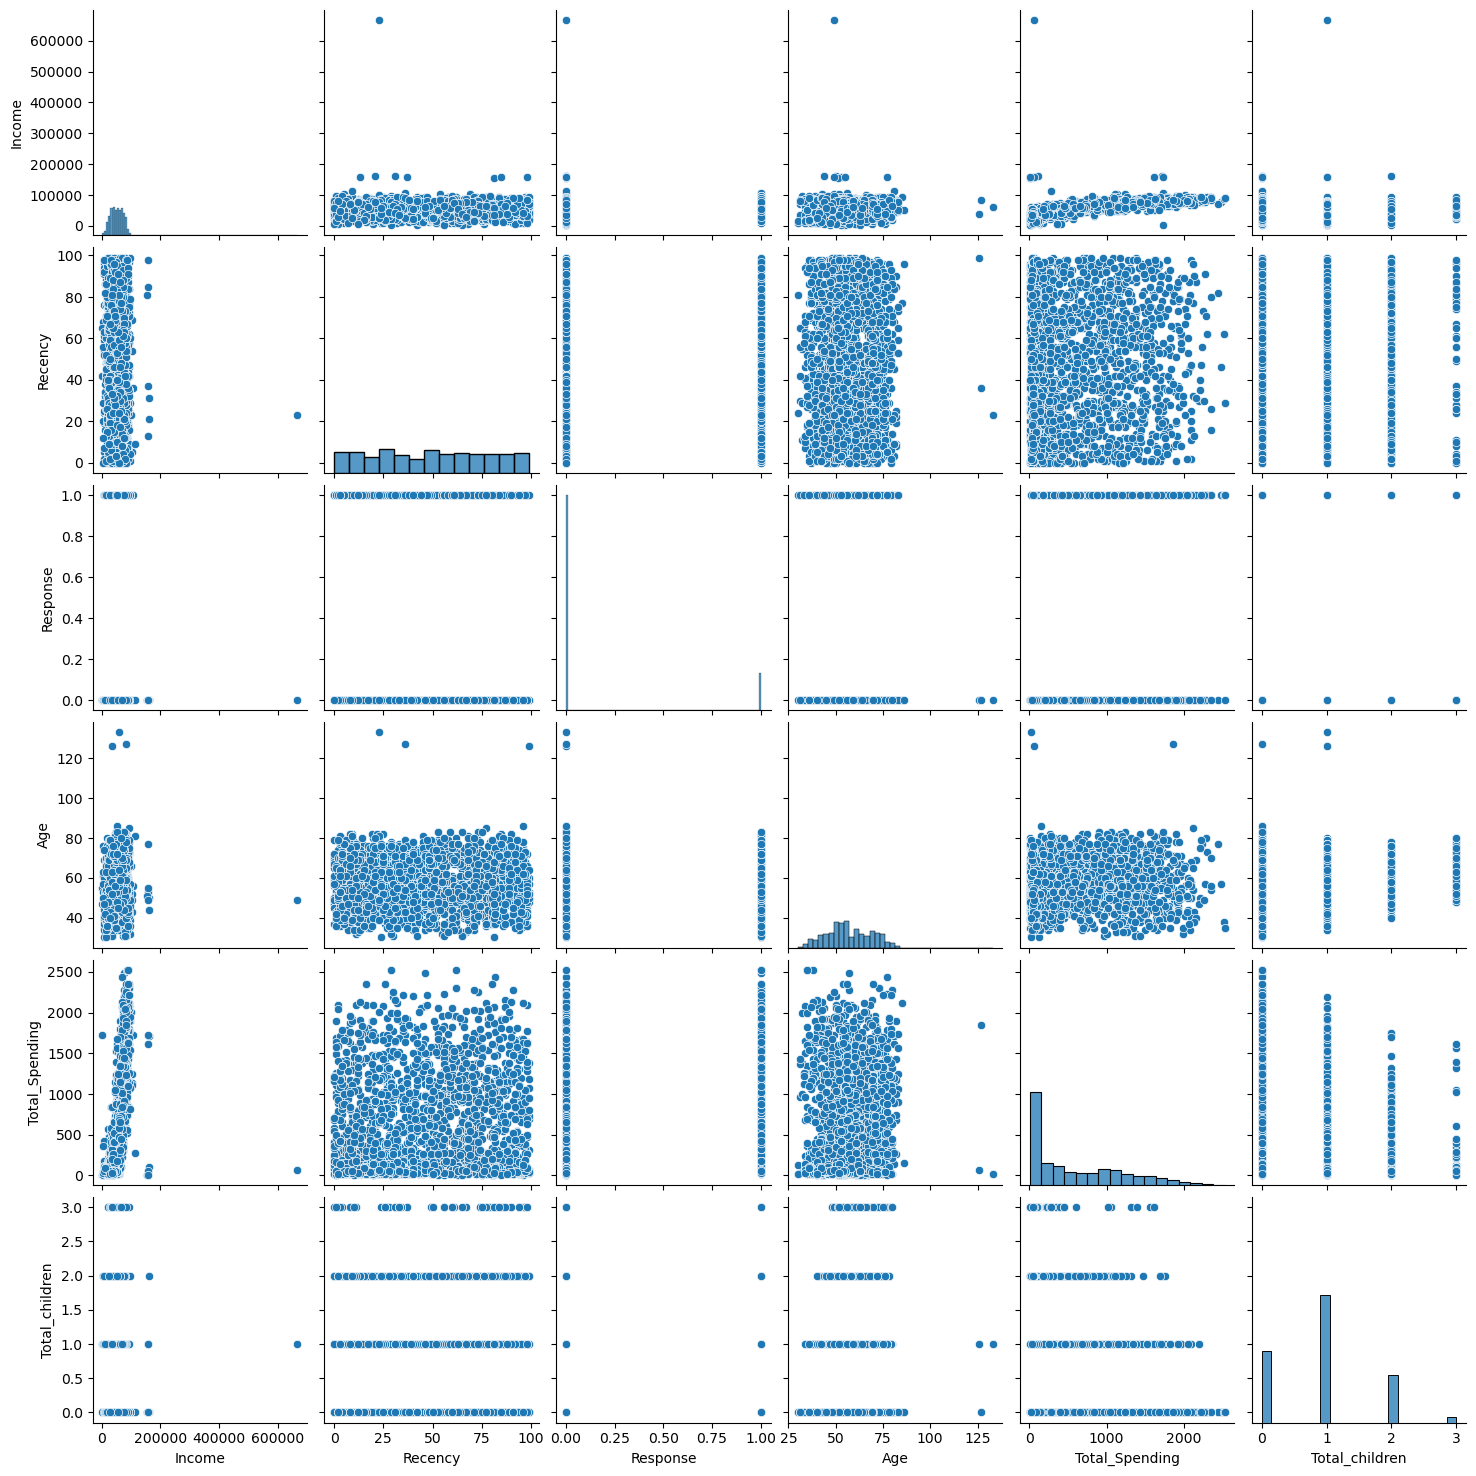

In [19]:
features = ["Income", "Recency", "Response", "Age", "Total_Spending", "Total_children"]

sns.pairplot(df_cleaned[features])

In [20]:
print("size of data with outliers :", len(df_cleaned))

df_cleaned = df_cleaned[(df_cleaned["Age"] < 90)]

df_cleaned = df_cleaned[(df_cleaned["Income"] < 500_000)]

print("size of data without outliers :", len(df_cleaned))

size of data with outliers : 2240
size of data without outliers : 2236


In [21]:
# encoding

from sklearn.preprocessing import OneHotEncoder

In [22]:
cat_cols = ["Education", "Marital_Status"]

df_encoded = pd.get_dummies(df_cleaned, columns=cat_cols, dtype=int)

In [23]:
df_encoded.head()

,Income,Recency,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age,Total_Spending,Total_children,Customer_Tenure_Days,Education_Graduate,Education_Master,Education_PhD,Education_Undergraduate,Marital_Status_Alone,Marital_Status_Partner
0,58138.0,58,3,8,10,4,7,0,1,69,1617,0,663,1,0,0,0,1,0
1,46344.0,38,2,1,1,2,5,0,0,72,27,2,113,1,0,0,0,1,0
2,71613.0,26,1,8,2,10,4,0,0,61,776,0,312,1,0,0,0,0,1
3,26646.0,26,2,2,0,4,6,0,0,42,53,1,139,1,0,0,0,0,1
4,58293.0,94,5,5,3,6,5,0,0,45,422,1,161,0,0,1,0,0,1


In [24]:
# Scaling

X = df_encoded

In [25]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [26]:
# visualizing

from sklearn.decomposition import PCA 

In [27]:
pca = PCA(n_components = 3)

X_pca = pca.fit_transform(X_scaled)

In [28]:
pca.explained_variance_ratio_

array([0.21946658, 0.10788256, 0.09588641])

Text(0.5, 0.92, '3d projection')

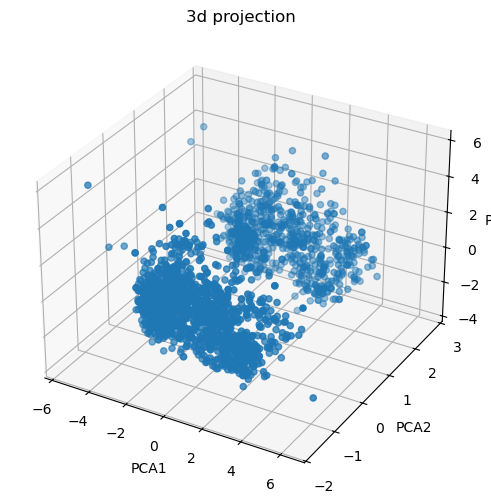

In [29]:
fig = plt.figure(figsize = (8,6))

ax = fig.add_subplot(111, projection= '3d')

ax.scatter(X_pca[:,0], X_pca[:,1], X_pca[:,2])

ax.set_xlabel("PCA1")
ax.set_ylabel("PCA2")
ax.set_zlabel("PCA3")
ax.set_title("3d projection")

In [30]:
# calculating the K value using Elbow method

from sklearn.cluster import KMeans
from kneed import KneeLocator

wcss = []

for k in range(1,11):
    kmeans = KMeans(n_clusters = k, random_state = 42)
    kmeans.fit_predict(X_pca)
    wcss.append(kmeans.inertia_)

<Axes: >

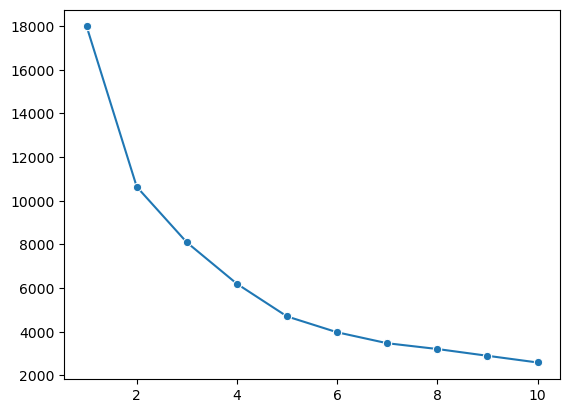

In [31]:
sns.lineplot(x = range(1,11), y = wcss, marker = 'o')

In [32]:
knee = KneeLocator(range(1,11), wcss, curve = "convex", direction = "decreasing")
print("optimal value for k :", knee.elbow)

optimal value for k : 4


In [33]:
# clustering

kmeans = KMeans(n_clusters = 4, random_state = 42)
labels_kmeans = kmeans.fit_predict(X_pca)

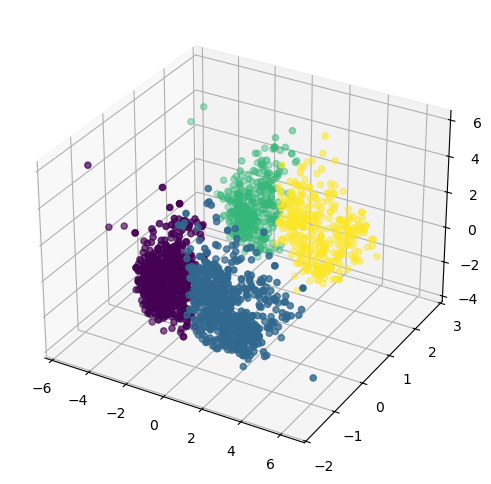

In [34]:
fig = plt.figure(figsize=(8,6))

ax = fig.add_subplot(111, projection = "3d")

ax.scatter(X_pca[:,0], X_pca[:,1], X_pca[:,2], c = labels_kmeans)

In [35]:
## Agglomerative Clustering
from sklearn.cluster import AgglomerativeClustering

In [36]:
agg = AgglomerativeClustering(n_clusters = 4, linkage = "ward")
labels_agg = agg.fit_predict(X_pca)

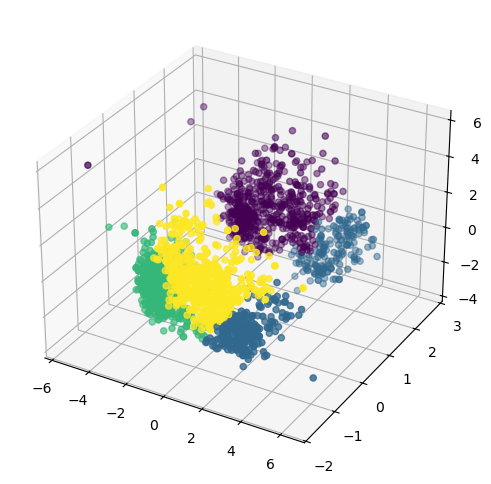

In [37]:
fig = plt.figure(figsize=(8,6))

ax = fig.add_subplot(111, projection = "3d")

ax.scatter(X_pca[:,0], X_pca[:,1], X_pca[:,2], c = labels_agg)

In [38]:
# charaterization of clusters

X["cluster"] = labels_kmeans

In [39]:
X.head()

,Income,Recency,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age,Total_Spending,Total_children,Customer_Tenure_Days,Education_Graduate,Education_Master,Education_PhD,Education_Undergraduate,Marital_Status_Alone,Marital_Status_Partner,cluster
0,58138.0,58,3,8,10,4,7,0,1,69,1617,0,663,1,0,0,0,1,0,3
1,46344.0,38,2,1,1,2,5,0,0,72,27,2,113,1,0,0,0,1,0,2
2,71613.0,26,1,8,2,10,4,0,0,61,776,0,312,1,0,0,0,0,1,1
3,26646.0,26,2,2,0,4,6,0,0,42,53,1,139,1,0,0,0,0,1,0
4,58293.0,94,5,5,3,6,5,0,0,45,422,1,161,0,0,1,0,0,1,0


<Axes: xlabel='cluster', ylabel='count'>

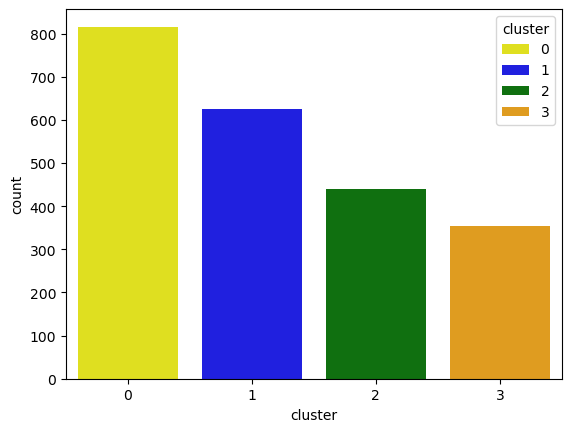

In [40]:
pal = ["yellow", "blue", "green", "orange"]
sns.countplot(x = X["cluster"], palette = pal, hue = X["cluster"])

<Axes: xlabel='Total_Spending', ylabel='Income'>

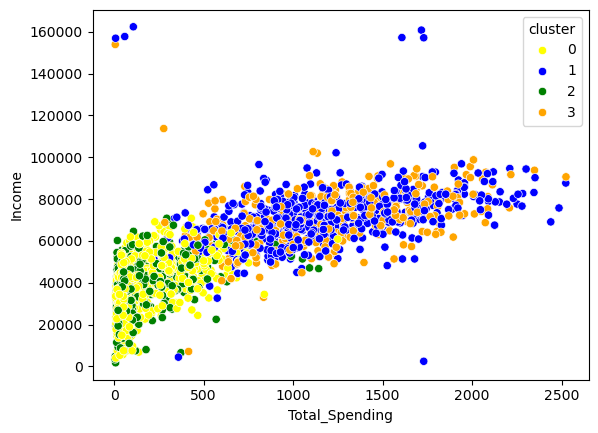

In [41]:
# Income & Spending patterns

sns.scatterplot(x=X["Total_Spending"], y=X["Income"], hue=X["cluster"], palette=pal)

## cluster summary

In [51]:
customer_count = X.groupby("cluster").size()

In [52]:
avg_spending = X.groupby("cluster")["Total_Spending"].mean()

In [53]:
total_spending = X.groupby("cluster")["Total_Spending"].sum()

In [58]:
# calc total purchases 

X["Total_Purchases"] = (X['NumWebPurchases'] + X['NumStorePurchases'] + X['NumCatalogPurchases'])

In [59]:
avg_purchases = X.groupby("cluster")["Total_Purchases"].mean()

In [60]:
response_rate = X.groupby("cluster")["Response"].mean()

In [71]:
# web conversion rate 
import numpy as np

X['Web_Conversion_Rate'] = (X['NumWebPurchases'] /X['NumWebVisitsMonth'].replace(0, np.nan)) * 100

conversion_rate = X.groupby("cluster")["Web_Conversion_Rate"].mean()

In [72]:
Overall_summary = pd.DataFrame({
    'customer_count': customer_count,
    'avg_spending': avg_spending,
    'total_spending': total_spending,
    'avg_purchases': avg_purchases,
    'response_rate': response_rate * 100,
    'Web_Conversion_Rate': conversion_rate
})


In [73]:
Overall_summary = Overall_summary.round(2)
Overall_summary 

,customer_count,avg_spending,total_spending,avg_purchases,response_rate,Web_Conversion_Rate
cluster,,,,,,
0,816,162.53,132622,7.34,7.23,44.88
1,626,1164.19,728781,19.32,15.81,187.45
2,440,165.77,72940,7.18,14.09,42.36
3,354,1188.26,420643,19.25,32.20,204.62


In [74]:
cluster_summary = X.groupby("cluster").mean()
print(cluster_summary)

               Income    Recency  NumDealsPurchases  NumWebPurchases  \
cluster                                                                
0        37290.460172  49.150735           2.526961         2.837010   
1        70891.574281  48.894569           2.153355         5.714058   
2        37160.872727  48.127273           2.554545         2.715909   
3        70644.406780  50.658192           1.884181         5.799435   

         NumCatalogPurchases  NumStorePurchases  NumWebVisitsMonth  Complain  \
cluster                                                                        
0                   0.769608           3.731618           6.531863  0.009804   
1                   5.087859           8.514377           3.752396  0.007987   
2                   0.827273           3.634091           6.579545  0.011364   
3                   5.022599           8.432203           3.725989  0.005650   

         Response        Age  ...  Total_children  Customer_Tenure_Days  \
cluster    